# Mammo-CLIP Training Curves
This notebook loads the TensorBoard event files from the scratch logs directory and visualizes validation AUC and losses for each fold.



## Setup
The code below points to the TensorBoard event files generated by the Mammo-CLIP run and pulls the scalar summaries into pandas data frames.


In [17]:
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd
import matplotlib.pyplot as plt

LOG_ROOT = Path("/hpcstor6/scratch01/a/a.kanamarlapudi001/mammo-clip/logs/RSNA/Classifier")
RUN_DIR = LOG_ROOT / "upmc_breast_clip_det_b5_period_n_ft" / "lr_5e-05_epochs_5_weighted_BCE_n_cancer_data_frac_1.0"
RUN_DIR


PosixPath('/hpcstor6/scratch01/a/a.kanamarlapudi001/mammo-clip/logs/RSNA/Classifier/upmc_breast_clip_det_b5_period_n_ft/lr_5e-05_epochs_5_weighted_BCE_n_cancer_data_frac_1.0')

In [18]:
def load_scalars(tag: str):
    records = []
    for fold_dir in sorted(RUN_DIR.iterdir()):
        if not fold_dir.is_dir():
            continue
        ea = event_accumulator.EventAccumulator(str(fold_dir))
        ea.Reload()
        if tag not in ea.Tags().get("scalars", []):
            continue
        for event in ea.Scalars(tag):
            records.append({
                "fold": fold_dir.name,
                "step": event.step,
                "value": event.value,
                "tag": tag,
            })
    df = pd.DataFrame.from_records(records)
    return df

def with_epoch_column(df: pd.DataFrame) -> pd.DataFrame:
    # Steps are monotonic for each fold; rank them to get sequential epoch numbers starting at 1
    df = df.copy()
    df["epoch"] = df.groupby("fold")["step"].rank(method="dense").astype(int)
    return df

val_auc = with_epoch_column(load_scalars("valid/cancer/AUC-ROC"))
train_loss = with_epoch_column(load_scalars("train/iter_loss"))
valid_loss = with_epoch_column(load_scalars("valid/iter_loss"))
train_lr = with_epoch_column(load_scalars("train/iter_lr"))

# Average duplicate entries within an epoch so the lines stay connected
val_auc_epoch = val_auc.groupby(["fold", "epoch"], as_index=False)["value"].mean()
valid_loss_epoch = valid_loss.groupby(["fold", "epoch"], as_index=False)["value"].mean()
train_loss_epoch = train_loss.groupby(["fold", "epoch"], as_index=False)["value"].mean()
train_lr_epoch = train_lr.groupby(["fold", "epoch"], as_index=False)["value"].mean()

val_auc_epoch.head()


,fold,epoch,value
0,fold0,1,0.789063
1,fold0,2,0.830160
2,fold0,3,0.844804
3,fold0,4,0.845262
4,fold0,5,0.846655


## Metrics by Epoch


### Validation AUC


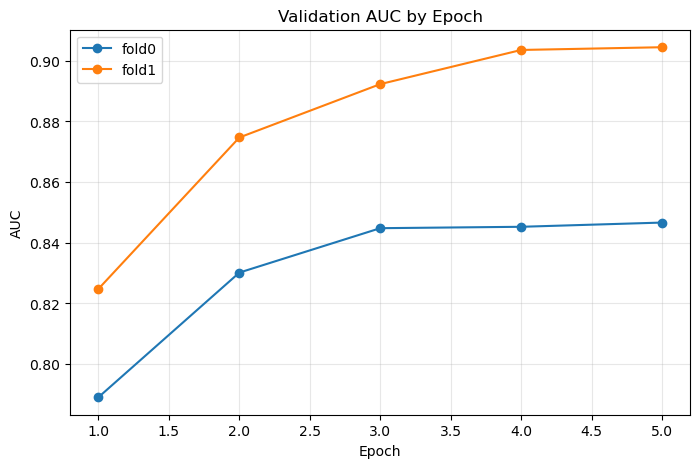

In [19]:
def plot_metric(df, title, ylabel, use_epoch=True, smooth=False):
    plt.figure(figsize=(8, 5))
    x_col = "epoch" if use_epoch and "epoch" in df.columns else "step"
    for fold, group in df.groupby("fold"):
        plot_df = group.sort_values(x_col)
        if smooth:
            plot_df = plot_df.groupby(x_col, as_index=False)["value"].mean()
        plt.plot(plot_df[x_col], plot_df["value"], marker="o", label=fold)
    plt.title(title)
    plt.xlabel(x_col.title())
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_metric(val_auc_epoch, "Validation AUC by Epoch", "AUC")


### Validation Loss


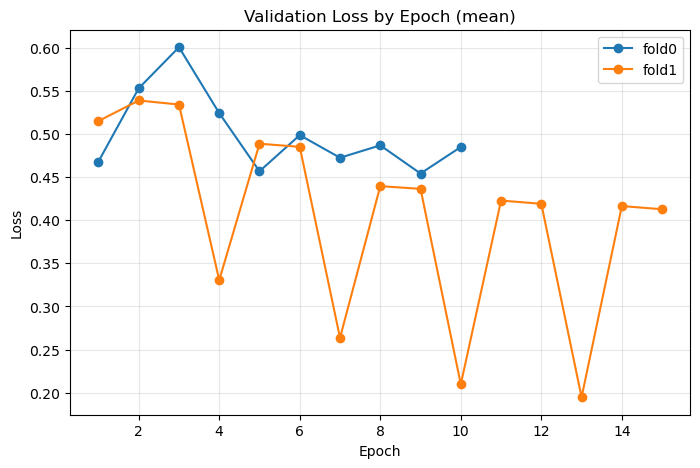

In [20]:
plot_metric(valid_loss_epoch, "Validation Loss by Epoch (mean)", "Loss")


### Training Loss


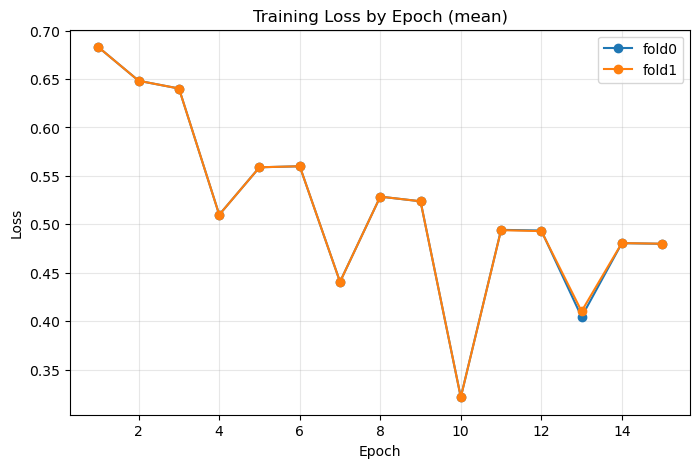

In [21]:
plot_metric(train_loss_epoch, "Training Loss by Epoch (mean)", "Loss")


### Learning Rate


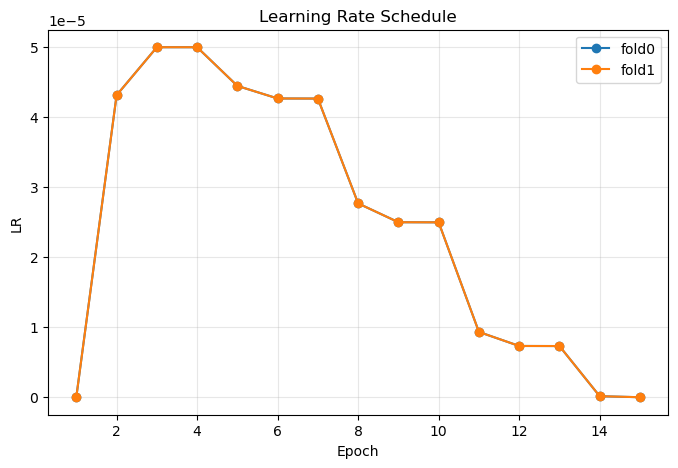

In [22]:
plot_metric(train_lr_epoch, "Learning Rate Schedule", "LR")
